# ***Importing Libraries***

In [ ]:
pip install catboost

In [314]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [270]:
df = pd.read_csv('/content/heart_disease_data.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [271]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [272]:
df.shape

(303, 14)

In [273]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [275]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [276]:
df.duplicated().sum()

np.int64(1)

In [277]:
df.drop_duplicates(inplace=True)

In [278]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [279]:
(df == 0).sum()

,0
age,0
sex,96
cp,143
trestbps,0
chol,0
fbs,257
restecg,147
thalach,0
exang,203
oldpeak,98


In [280]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


In [281]:
df.cov()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,81.865757,-0.400761,-0.589283,44.991573,97.031561,0.385635,-0.531110,-81.904755,0.396570,2.165226,-0.915161,2.753306,0.362291,-0.999890
sex,-0.400761,0.217553,-0.024906,-0.472245,-4.720930,0.007657,-0.014807,-0.496095,0.031462,0.053264,-0.009483,0.053090,0.060461,-0.066005
cp,-0.589283,-0.024906,1.065114,0.842622,-3.882060,0.035346,0.022563,6.934435,-0.190678,-0.175836,0.074322,-0.202977,-0.101461,0.222503
trestbps,44.991573,-0.472245,0.842622,308.472817,113.853821,1.115883,-1.065851,-19.317793,0.565906,3.969653,-1.329960,1.754901,0.676905,-1.281842
chol,97.031561,-4.720930,-3.882060,113.853821,2678.423588,0.210963,-4.018272,-6.292359,1.559801,3.010631,0.013289,4.526578,3.071429,-2.102990
fbs,0.385635,0.007657,0.035346,1.115883,0.210963,0.127225,-0.015588,-0.058569,0.004147,0.001870,-0.012893,0.052045,-0.007162,-0.004774
restecg,-0.531110,-0.014807,0.022563,-1.065851,-4.018272,-0.015588,0.276705,0.496491,-0.017018,-0.034367,0.029306,-0.044014,-0.003377,0.035401
thalach,-81.904755,-0.496095,6.934435,-19.317793,-6.292359,-0.058569,0.496491,524.571561,-4.064399,-9.103003,5.430750,-5.264417,-1.332578,4.799322
exang,0.396570,0.031462,-0.190678,0.565906,1.559801,0.004147,-0.017018,-4.064399,0.221084,0.156606,-0.074212,0.059350,0.059328,-0.102198
oldpeak,2.165226,0.053264,-0.175836,3.969653,3.010631,0.001870,-0.034367,-9.103003,0.156606,1.348971,-0.412510,0.276608,0.148872,-0.248703


In [282]:
df.skew()

,0
age,-0.203743
sex,-0.786120
cp,0.493022
trestbps,0.716541
chol,1.147332
fbs,1.981201
restecg,0.169467
thalach,-0.532671
exang,0.737281
oldpeak,1.266173


In [283]:
df.kurtosis()

,0
age,-0.527512
sex,-1.391273
cp,-1.183729
trestbps,0.922996
chol,4.542591
fbs,1.937947
restecg,-1.359464
thalach,-0.062186
exang,-1.466170
oldpeak,1.567876


In [284]:
df.quantile([0.25, 0.50, 0.75, 0.95, 0.99])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0.25,48.0,0.0,0.0,120.0,211.00,0.0,0.00,133.25,0.0,0.0,1.0,0.00,2.0,0.0
0.50,55.5,1.0,1.0,130.0,240.50,0.0,1.00,152.50,0.0,0.8,1.0,0.00,2.0,1.0
0.75,61.0,1.0,2.0,140.0,274.75,0.0,1.00,166.00,1.0,1.6,2.0,1.00,3.0,1.0
0.95,68.0,1.0,3.0,160.0,326.95,1.0,1.00,181.95,1.0,3.4,2.0,3.00,3.0,1.0
0.99,71.0,1.0,3.0,180.0,406.87,1.0,1.99,191.98,1.0,4.2,2.0,3.99,3.0,1.0


In [285]:
df["target"].value_counts()/df["target"].shape*100

,count
target,
1,54.304636
0,45.695364


In [286]:
df.groupby('sex')['target'].value_counts(normalize=True) * 100

sex  target
0    1         75.000000
     0         25.000000
1    0         55.339806
     1         44.660194
Name: proportion, dtype: float64

In [287]:
df.groupby('target')[['trestbps', 'chol', 'thalach']].mean()

,trestbps,chol,thalach
target,,,
0,134.398551,251.086957,139.101449
1,129.250000,242.640244,158.378049


In [288]:
df.groupby('fbs')['target'].mean()

,target
fbs,
0,0.548638
1,0.511111


In [289]:
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 60, 100], labels=['Young', 'Middle-aged', 'Senior'])

df.groupby('age_group')['target'].mean()

,target
age_group,
Young,0.666667
Middle-aged,0.570732
Senior,0.443038


In [290]:
num_df = df.select_dtypes(include="number")
cat_df = df.select_dtypes(exclude="number")

# *Data Visualization*

<Axes: >

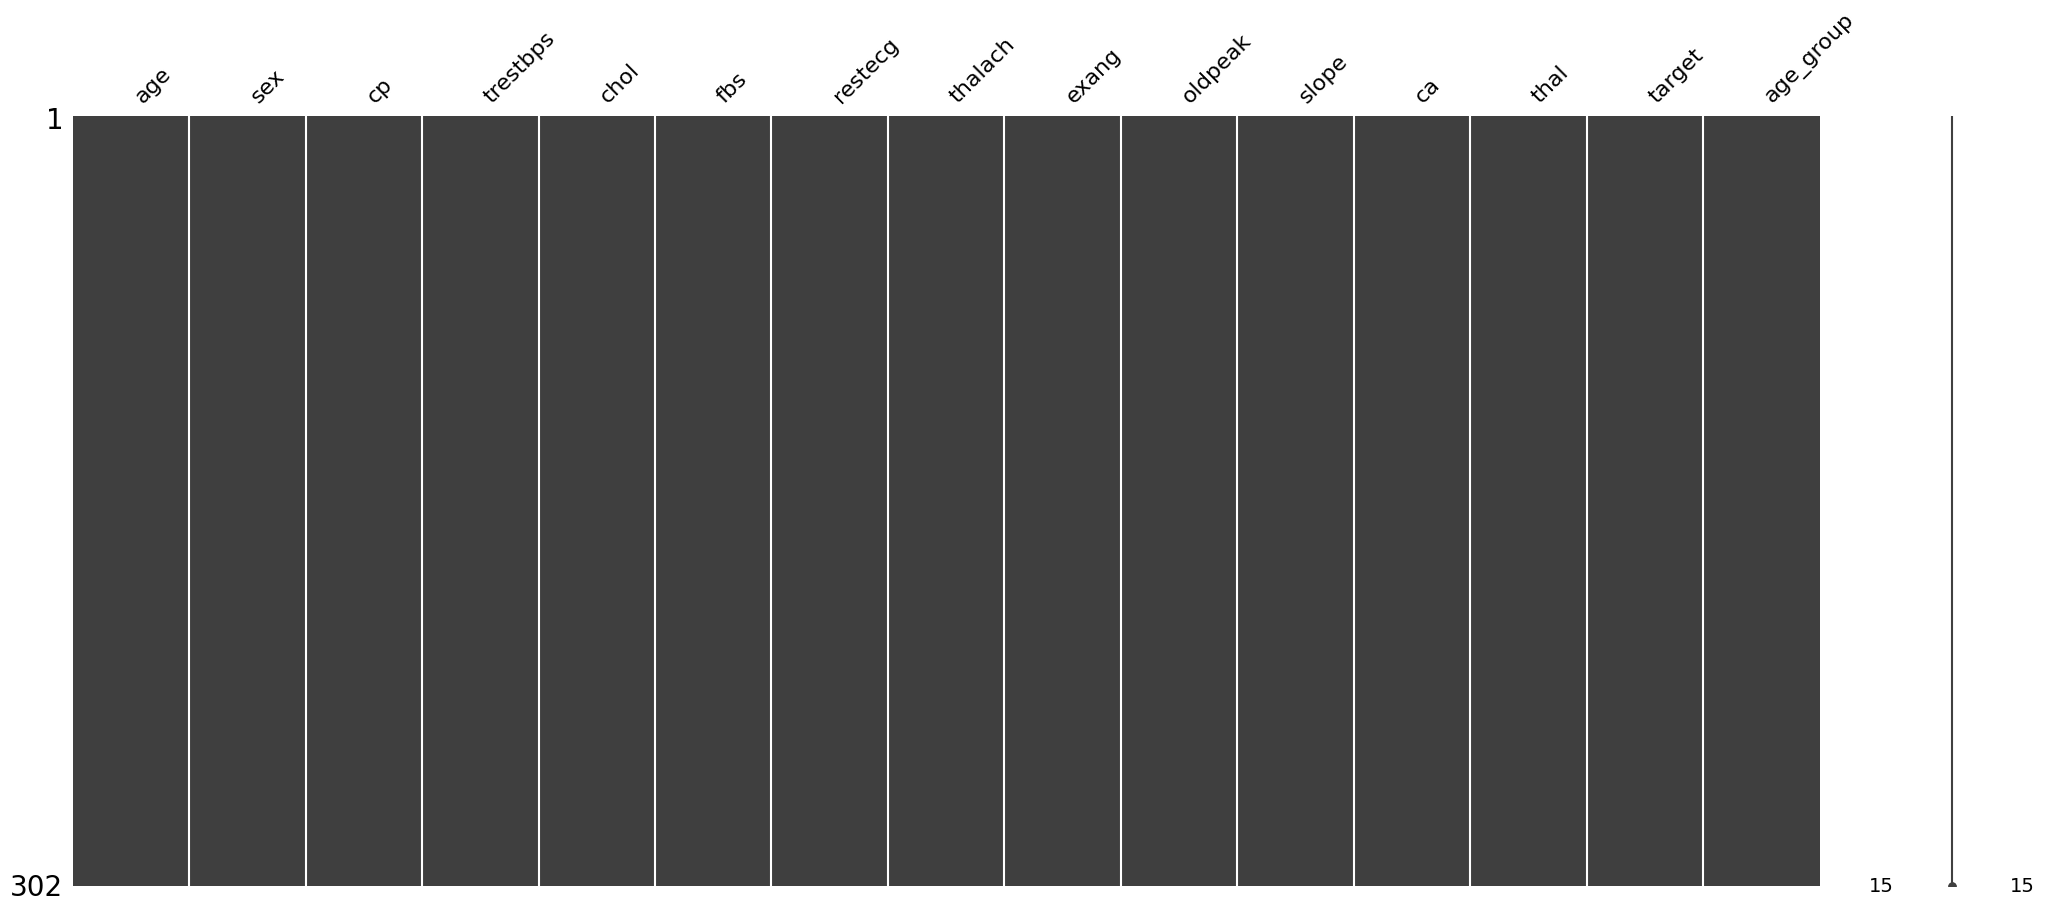

In [291]:
import missingno
missingno.matrix(df)

<Axes: >

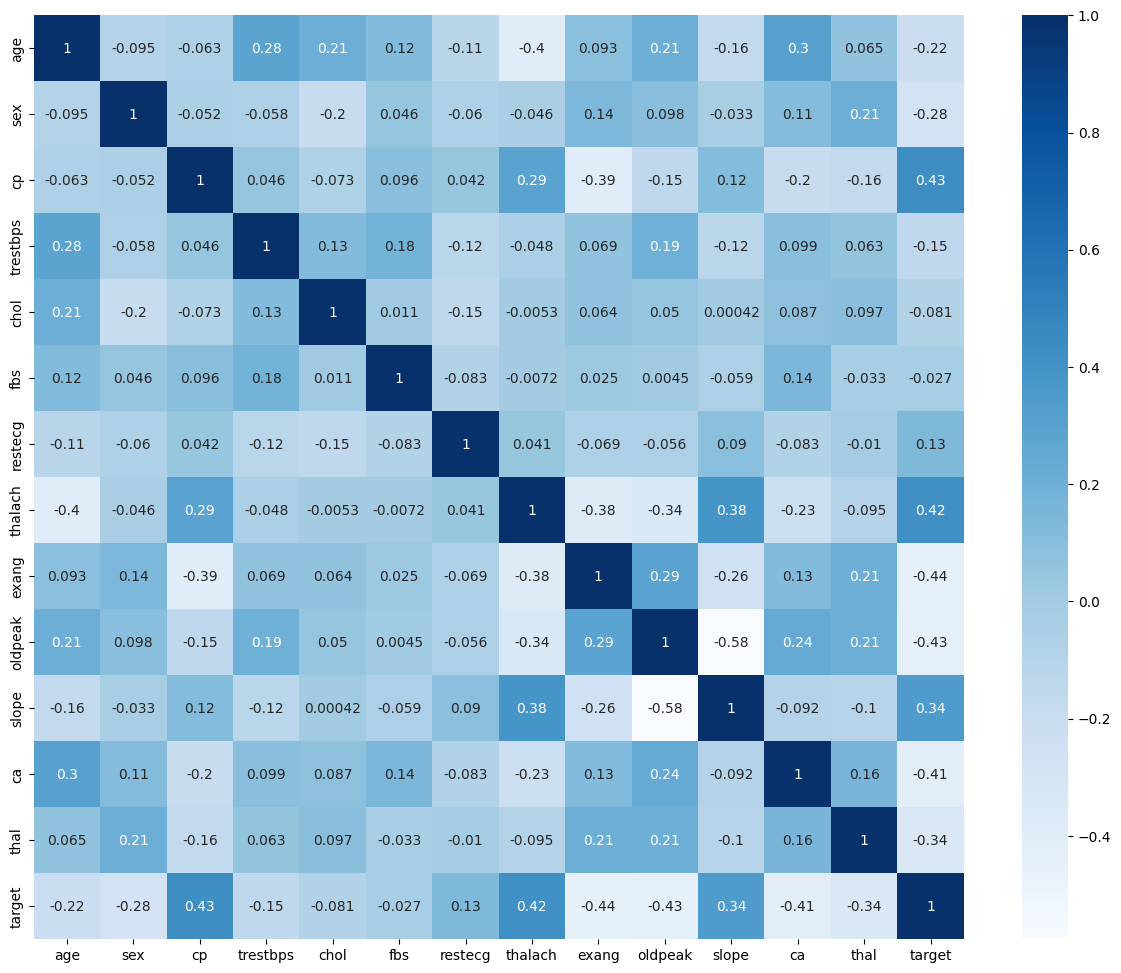

In [292]:
plt.figure(figsize=(15,12))
sns.heatmap(num_df.corr(), annot=True, cmap='Blues')

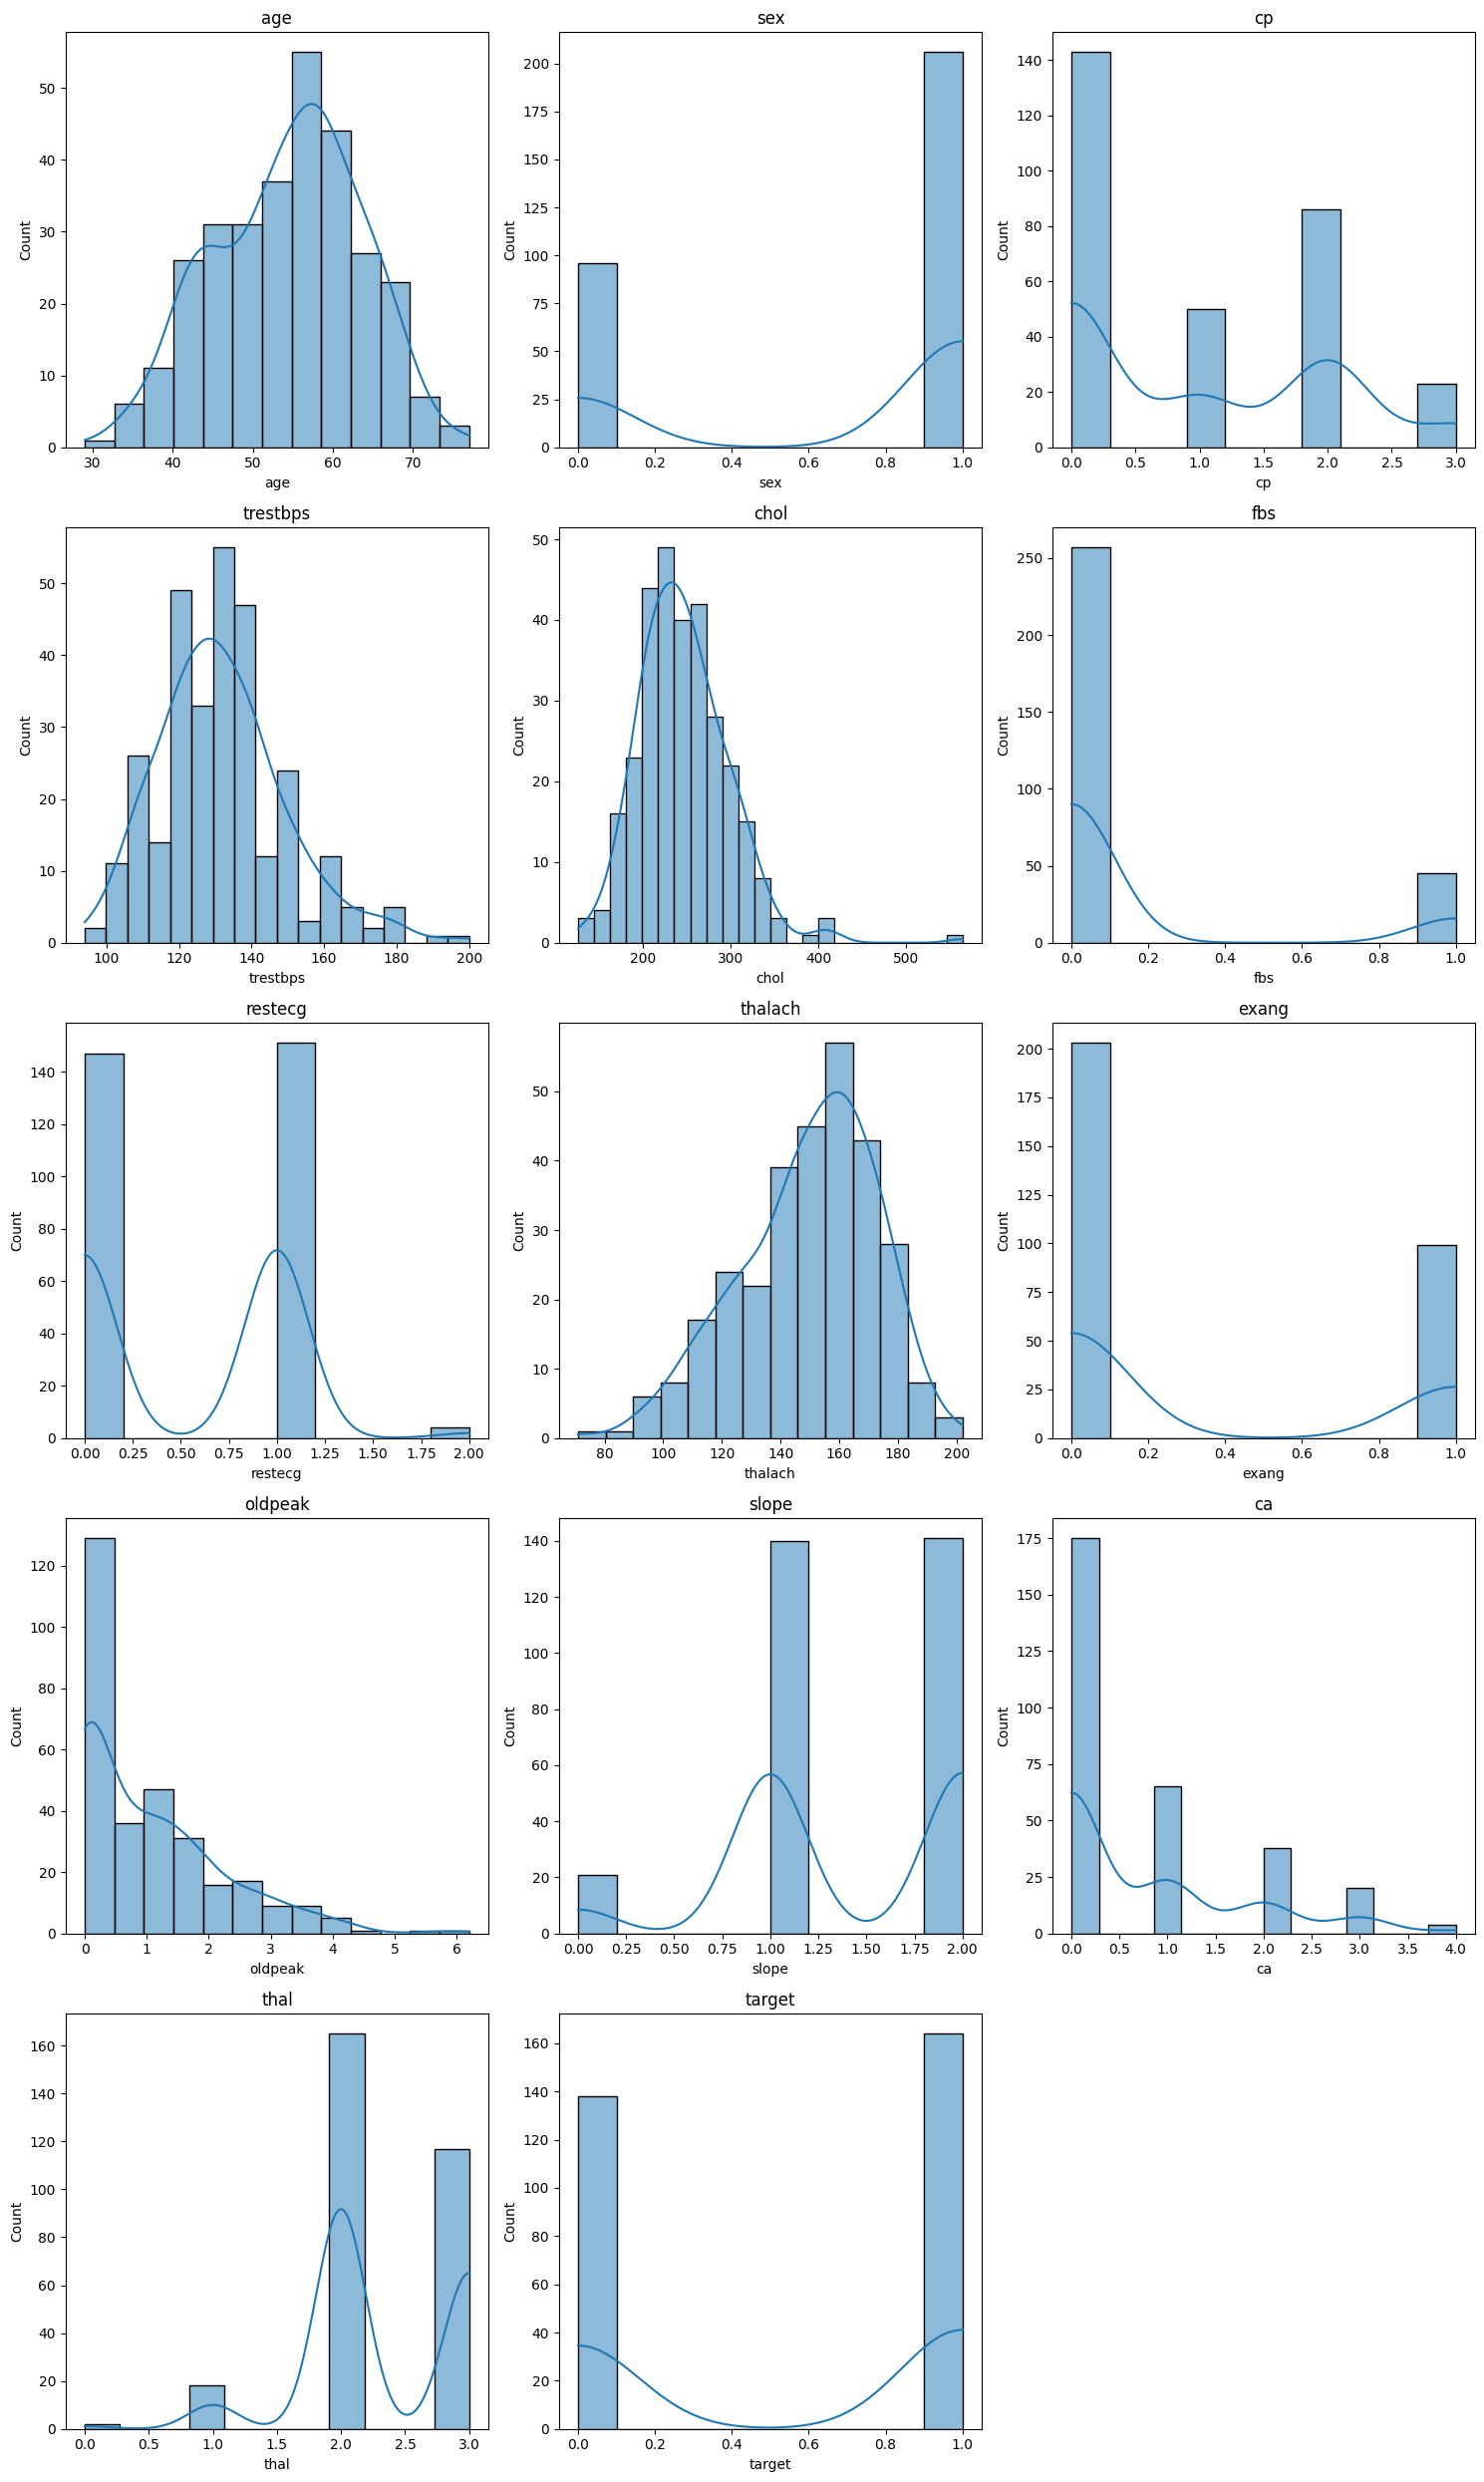

In [293]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(num_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

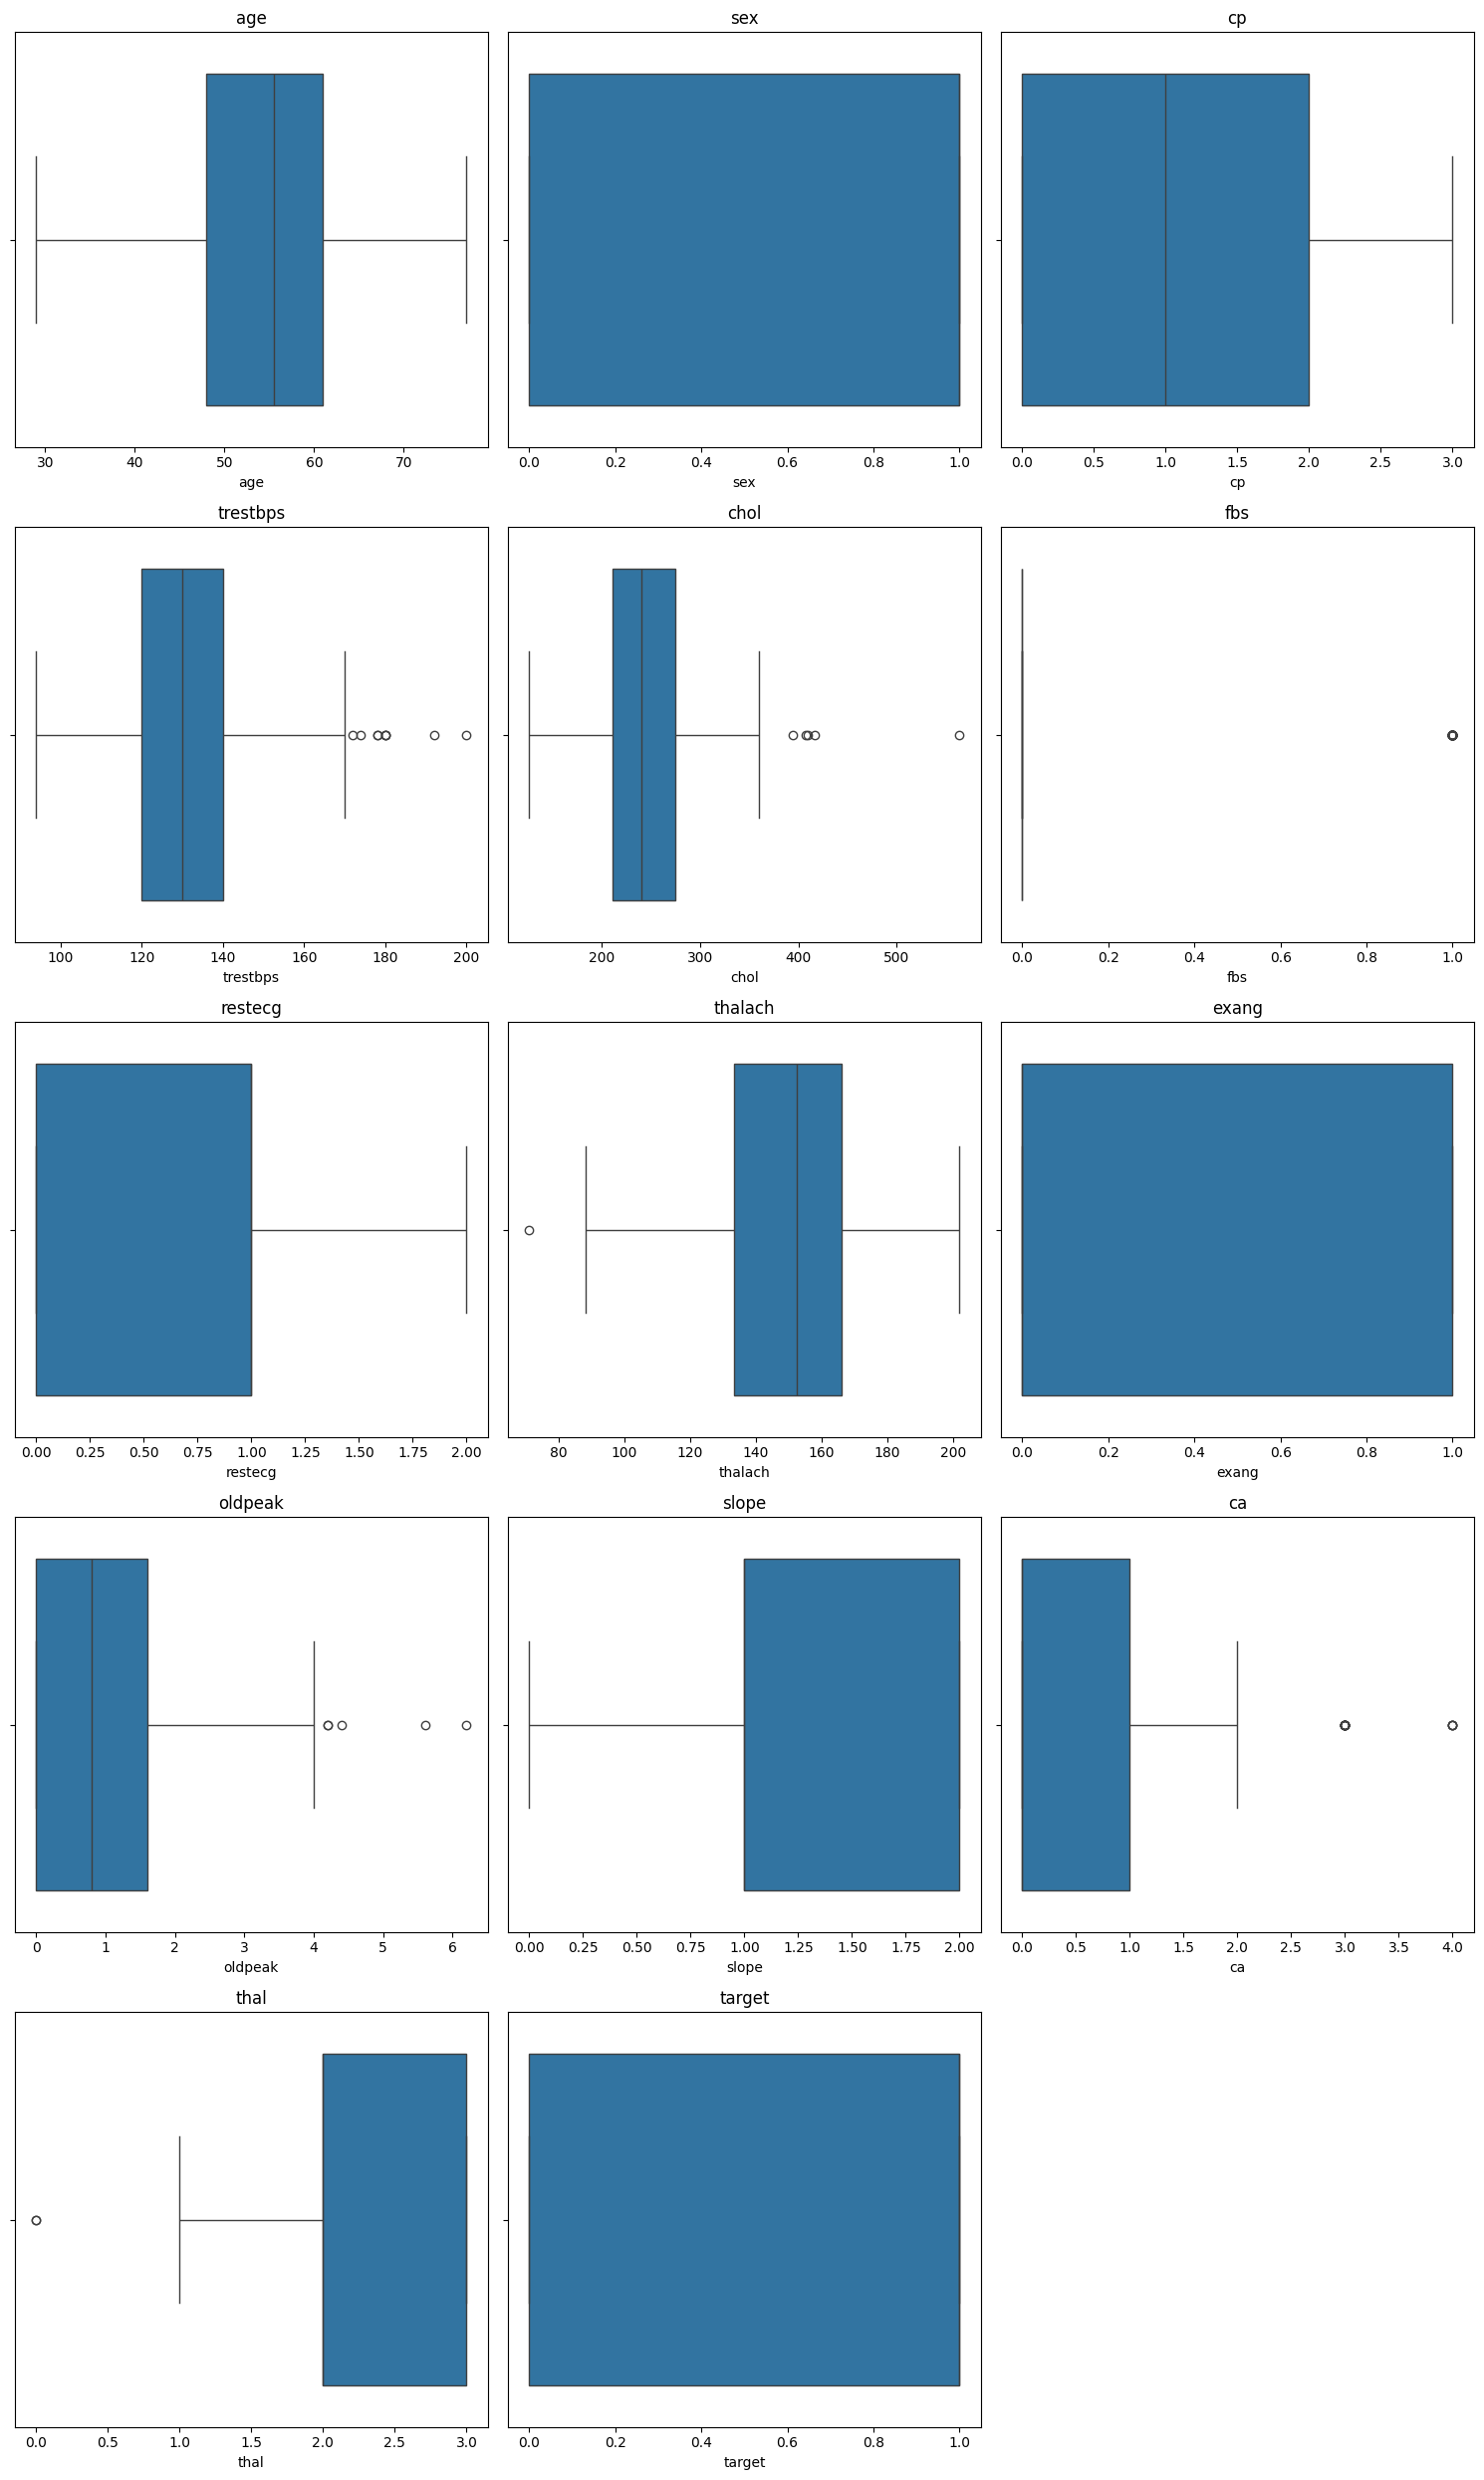

In [294]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='target', ylabel='count'>

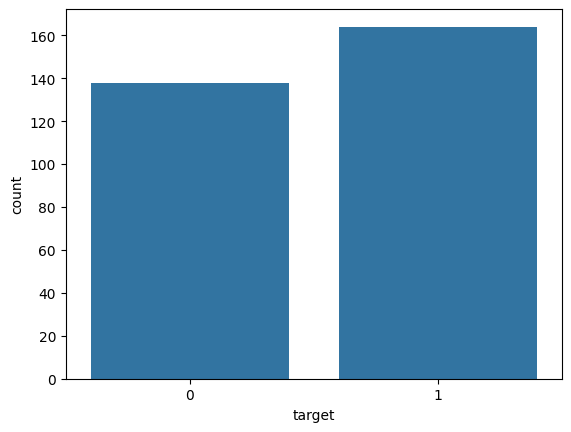

In [295]:
sns.countplot(x="target",data=df)

<Axes: xlabel='target', ylabel='count'>

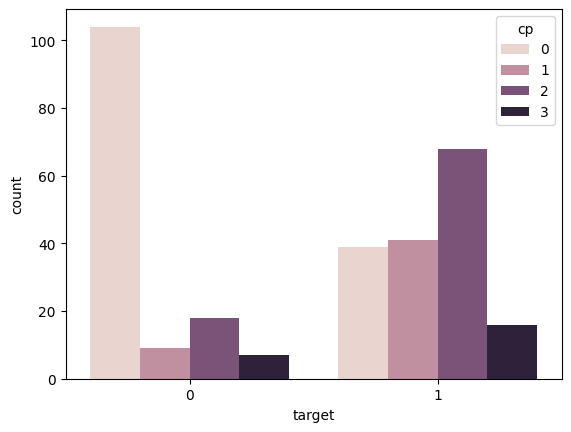

In [296]:
sns.countplot(x="target",data=df,hue="cp")

<Axes: xlabel='target', ylabel='count'>

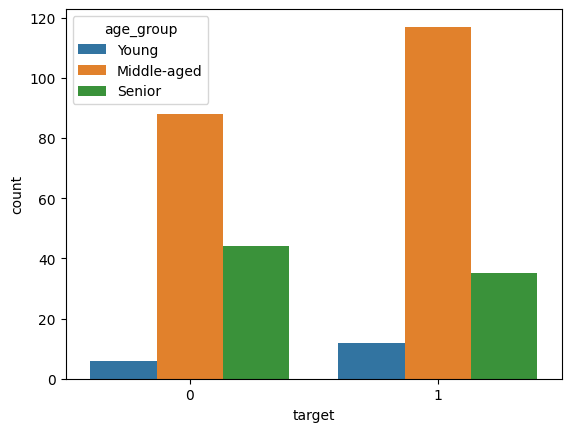

In [297]:
sns.countplot(x="target",data=df,hue="age_group")

# ***Data Preprocessing***

In [298]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)

In [299]:
num_df["oldpeak"]=np.log1p(num_df["oldpeak"])

In [300]:
cat_df["age_group"] = cat_df["age_group"].map({"Young":0,"Middle-aged":1,"Senior":2}).astype(int)

In [301]:
df = pd.concat([num_df,cat_df],axis=1)
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group
0,63,1,3,145,233.0,0,0,150.0,0,1.193922,0,0.0,1.0,1,2
1,37,1,2,130,250.0,0,1,187.0,0,1.504077,0,0.0,2.0,1,0
2,41,0,1,130,204.0,0,0,172.0,0,0.875469,2,0.0,2.0,1,1
3,56,1,1,120,236.0,0,1,178.0,0,0.587787,2,0.0,2.0,1,1
4,57,0,0,120,354.0,0,1,163.0,1,0.470004,2,0.0,2.0,1,1


In [302]:
df['age_group'].dtype

dtype('int64')

In [303]:
X = df.drop("target",axis=1)
y = df["target"]

In [304]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [305]:
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [327]:
models = {
    "KNN": (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3,5,7,9],
            'weights': ['uniform','distance']
        }
    ),

    "LogisticRegression": (
        LogisticRegression(max_iter=1000,class_weight='balanced'),
        {
            'C': [0.01,0.1,1,10]
        }
    ),

    "DecisionTree": (
        DecisionTreeClassifier(class_weight='balanced'),
        {
            'max_depth': [None,5,10,20],
            'min_samples_split': [2,5,10]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(class_weight='balanced'),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(),
        {
            'n_estimators': [50,100],
            'learning_rate': [0.01,0.1,1]
        }
    ),

    "ExtraTrees": (
        ExtraTreesClassifier(),
        {
            'n_estimators': [100,200],
            'max_depth': [None,10,20]
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1],
            'max_depth': [3,6]
        }
    ),

    "LightGBM": (
        LGBMClassifier(verbose=-1),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(silent=True),
        {
            'iterations': [100,200],
            'learning_rate': [0.01,0.1],
            'depth': [4,6]
        }
    )
}

In [328]:
results = []

for name, (model, param_grid) in models.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    if hasattr(best_model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Best Params": best_params,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
    })

Training KNN...
Training LogisticRegression...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...
Training AdaBoost...
Training ExtraTrees...
Training XGBoost...
Training LightGBM...
Training CatBoost...


In [329]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)
results_df

,Model,Best Params,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,CatBoost,"{'depth': 4, 'iterations': 200, 'learning_rate...",0.912863,0.852459,0.800000,0.969697,0.876712,0.914502
1,LightGBM,"{'learning_rate': 0.01, 'n_estimators': 100}",0.854772,0.819672,0.761905,0.969697,0.853333,0.904221
2,XGBoost,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.908714,0.836066,0.780488,0.969697,0.864865,0.891775
3,AdaBoost,"{'learning_rate': 0.1, 'n_estimators': 50}",0.846473,0.786885,0.738095,0.939394,0.826667,0.896104
4,GradientBoosting,"{'learning_rate': 0.01, 'n_estimators': 200}",0.929461,0.836066,0.794872,0.939394,0.861111,0.887446
5,RandomForest,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.950207,0.803279,0.756098,0.939394,0.837838,0.900433
6,DecisionTree,"{'max_depth': 5, 'min_samples_split': 2}",0.921162,0.803279,0.769231,0.909091,0.833333,0.789502
7,LogisticRegression,{'C': 1},0.863071,0.803279,0.769231,0.909091,0.833333,0.891775
8,ExtraTrees,"{'max_depth': 20, 'n_estimators': 100}",1.000000,0.754098,0.725000,0.878788,0.794521,0.903680
9,KNN,"{'n_neighbors': 7, 'weights': 'uniform'}",0.734440,0.622951,0.638889,0.696970,0.666667,0.662338


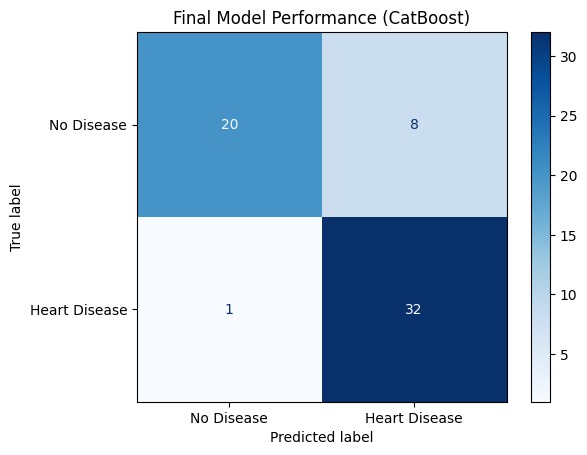

In [330]:
final_model = CatBoostClassifier(depth= 4, iterations= 200, learning_rate= 0.01,silent=True)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
disp.plot(cmap='Blues')
plt.title('Final Model Performance (CatBoost)')
plt.show()

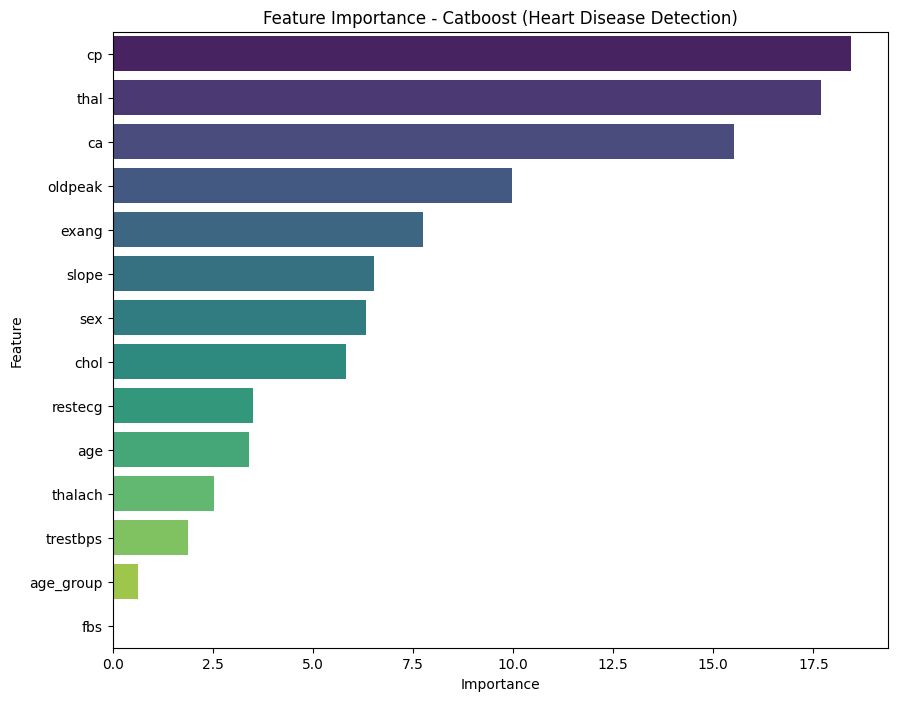

In [317]:
importances = final_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - Catboost (Heart Disease Detection)')
plt.show()

In [320]:
print(feature_importance_df)

      Feature  Importance
2          cp   18.436676
12       thal   17.690363
11         ca   15.513554
9     oldpeak    9.974360
8       exang    7.755328
10      slope    6.527118
1         sex    6.316177
4        chol    5.832570
6     restecg    3.498241
0         age    3.413527
7     thalach    2.530008
3    trestbps    1.879608
13  age_group    0.632470
5         fbs    0.000000


In [322]:
import joblib

joblib.dump(final_model, 'heart_disease_catboost_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']